In [635]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 

In [636]:
with open("../data/02-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/02-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/trials_df.pkl","rb") as f:
    trials_df =pickle.load(f)
with open("../data/02-result/indications_df.pkl","rb") as f:
    indications_df =pickle.load(f)
with open("../data/01-result/embeddings_df.pkl","rb") as f:
    embeddings_df =pickle.load(f)
with open("../data/01-result/fingerprints_df.pkl","rb") as f:
    fingerprints_df =pickle.load(f)

# Overview

In [637]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (2314, 95)
Diseases:
    (197, 58)
Trials:
    (7023, 11)
Indications:
    (7637, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


In [638]:
indications_df["overall_success"].value_counts()

overall_success
False    2184
True     1052
Name: count, dtype: Int64

# Missing values before merging

In [639]:
# drugs_df.isnull().sum().sort_values(ascending=False)
drugs_df = drugs_df.dropna(subset=["targets"])
drugs_df = drugs_df[drugs_df.drug_path_str.str.len()>0]
drugs_df = drugs_df[~drugs_df["biotherapeutic"].astype(bool)]
drugs_df = drugs_df[~drugs_df["withdrawn_flag"]]
drugs_df = drugs_df.drop(columns=["max_phase","helm_notation", "first_approval", "usan_year", "usan_stem_definition",
                                  "standard_inchi_key", "standard_inchi", "canonical_smiles", "full_molformula",
                                  "withdrawn_flag", "black_box_warning", "first_in_class", "molecule_type",
                                  "biotherapeutic", "targets", "drug_path_str"])

diseases_df  = diseases_df[diseases_df.disease_path_str.str.len()>0]
diseases_df = diseases_df.drop(columns=["description", "associatedTargets", "phenotypes",
                                         "disease_targets", "disease_path_str"])


indications_df = indications_df.dropna(subset=["overall_success"])

In [640]:
print(f"Drugs:\n    {drugs_df.shape}")
print(f"Diseases:\n    {diseases_df.shape}")
print(f"Trials:\n    {trials_df.shape}")
print(f"Indications:\n    {indications_df.shape}")
print(f"Name embeddings:\n    {embeddings_df.shape}")
print(f"Molecular ingerprints:\n    {fingerprints_df.shape}")

Drugs:
    (831, 79)
Diseases:
    (196, 53)
Trials:
    (7023, 11)
Indications:
    (3236, 10)
Name embeddings:
    (489939, 5)
Molecular ingerprints:
    (1547, 101)


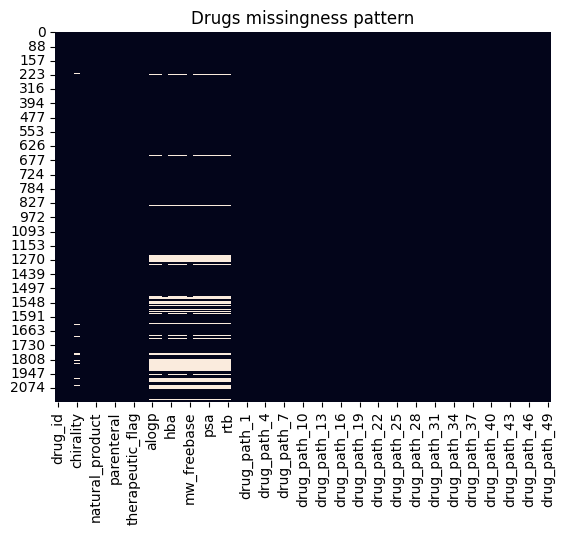

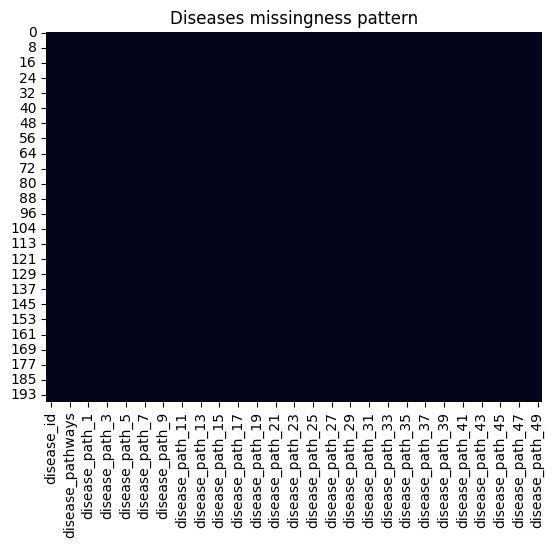

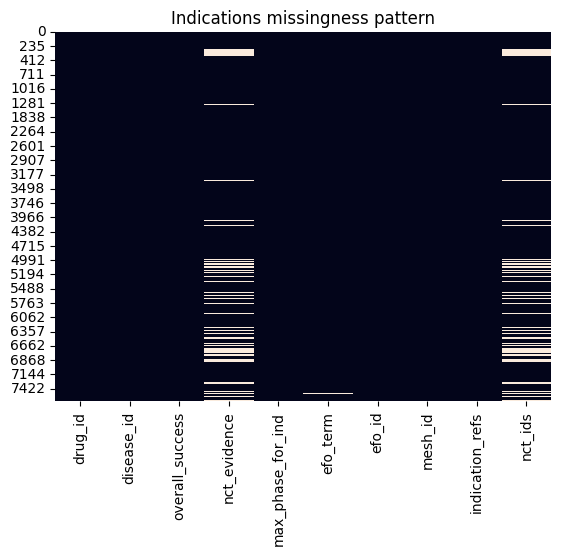

In [641]:
sns.heatmap(drugs_df.isnull(), cbar=False)
plt.title("Drugs missingness pattern")
plt.show()
sns.heatmap(diseases_df.isnull(), cbar=False)
plt.title("Diseases missingness pattern")
plt.show()
sns.heatmap(indications_df.isnull(), cbar=False)
plt.title("Indications missingness pattern")
plt.show()

In [642]:
encoded = pd.get_dummies(drugs_df["chirality"], drop_first=True, dummy_na=True, prefix="chirality_").astype(int) # "achiral" as baseline
drugs_df = drugs_df.drop(columns=["chirality"]).join(encoded)

should_be_num_features = ["dosed_ingredient", "alogp","full_mwt",
             "mw_freebase", "np_likeness_score", "psa", "qed_weighted"]
for col in should_be_num_features:
    drugs_df[col] = pd.to_numeric(drugs_df[col], errors="coerce")

drugs_df["ro3_pass"] = drugs_df["ro3_pass"].str.lower().map({"y": 1, "n":0})

knn_imp = KNNImputer(n_neighbors=5)
num_features = drugs_df.select_dtypes(include=np.number).columns
drugs_df[num_features] = knn_imp.fit_transform(drugs_df[num_features])

# Merge all

In [643]:
drugs_df = drugs_df.merge(fingerprints_df, on="drug_id")
diseases_df["disease_id"] = diseases_df["disease_id"].str.replace("_",":")
embeddings_df["disease_id"] = embeddings_df["disease_id"].str.replace("_",":")
merged_df = (indications_df[["drug_id", "disease_id", "overall_success"]]
             .merge(drugs_df, on="drug_id")
             .merge(diseases_df, on="disease_id")
             .merge(embeddings_df[["drug_id", "disease_id","name_similarity"]], on =["drug_id", "disease_id"]))

In [644]:
merged_df["disease_name"]

0                                  lymphoma
1                             atopic eczema
2                         allergic rhinitis
3             juvenile idiopathic arthritis
4                      rheumatoid arthritis
                       ...                 
1178                  non-Hodgkins lymphoma
1179                 IGA glomerulonephritis
1180                       multiple myeloma
1181                   Mantle cell lymphoma
1182    autoimmune thrombocytopenic purpura
Name: disease_name, Length: 1183, dtype: object

In [645]:
merged_df = (merged_df[["drug_id","disease_id", "drug_name", "disease_name"]]
             .join(merged_df.select_dtypes(exclude=["object"])))
merged_df = merged_df.rename(columns={"overall_success" : "success"})
merged_df = merged_df.dropna(subset=["success"])
merged_df

,drug_id,disease_id,drug_name,disease_name,success,chemical_probe,dosed_ingredient,inorganic_flag,natural_product,oral,...,disease_path_41,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity
0,CHEMBL1467,EFO:0000574,allopurinol,lymphoma,True,0.0,True,0.0,1.0,True,...,0.005239,0.029122,-0.016002,0.079853,0.020295,-0.010043,0.036285,0.005089,0.042312,0.075028
1,CHEMBL514800,EFO:0000274,apremilast,atopic eczema,False,0.0,True,0.0,1.0,True,...,-0.020228,-0.007647,-0.078747,-0.050006,0.065512,-0.011153,0.089468,0.046286,0.097443,0.094691
2,CHEMBL1370,EFO:0005854,budesonide,allergic rhinitis,True,0.0,True,0.0,1.0,True,...,0.048651,-0.002516,0.138820,-0.022043,-0.046279,0.046063,0.005258,0.015994,0.076821,0.249712
3,CHEMBL118,EFO:0002609,celecoxib,juvenile idiopathic arthritis,True,0.0,True,0.0,0.0,True,...,0.034670,-0.013284,0.045651,0.080481,-0.062777,0.025146,-0.013067,0.021488,-0.002977,0.125380
4,CHEMBL118,EFO:0000685,celecoxib,rheumatoid arthritis,True,0.0,True,0.0,0.0,True,...,0.018464,-0.057149,0.012485,-0.016685,0.028022,0.021635,-0.030254,-0.056211,-0.044441,0.221504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178,CHEMBL4647810,EFO:0005952,elimusertib,non-Hodgkins lymphoma,False,0.0,False,0.0,0.0,False,...,-0.015753,0.026205,0.024638,0.050006,0.034497,0.001371,0.022380,0.002135,0.033640,0.010902
1179,CHEMBL5095401,EFO:0004194,iptacopan hydrochloride,IGA glomerulonephritis,True,0.0,True,0.0,0.0,True,...,-0.033574,0.016008,-0.078126,-0.125055,-0.017658,0.022526,-0.014772,-0.028396,0.001880,0.096047
1180,CHEMBL5315122,EFO:0001378,bortezomib d-mannitol,multiple myeloma,True,0.0,True,0.0,0.0,False,...,-0.003793,0.025983,0.016401,-0.099410,0.044344,-0.024868,-0.031682,0.029144,0.072834,0.373565
1181,CHEMBL5315122,EFO:1001469,bortezomib d-mannitol,Mantle cell lymphoma,True,0.0,True,0.0,0.0,False,...,-0.002496,-0.009736,-0.038252,-0.034740,0.023610,0.010268,0.024163,-0.022099,0.004296,0.106201


In [646]:
print(f"Merged data:\n  {merged_df.shape}")
merged_df["success"].value_counts()

Merged data:
  (1183, 233)


success
False    669
True     514
Name: count, dtype: Int64

# Correlations and distributions

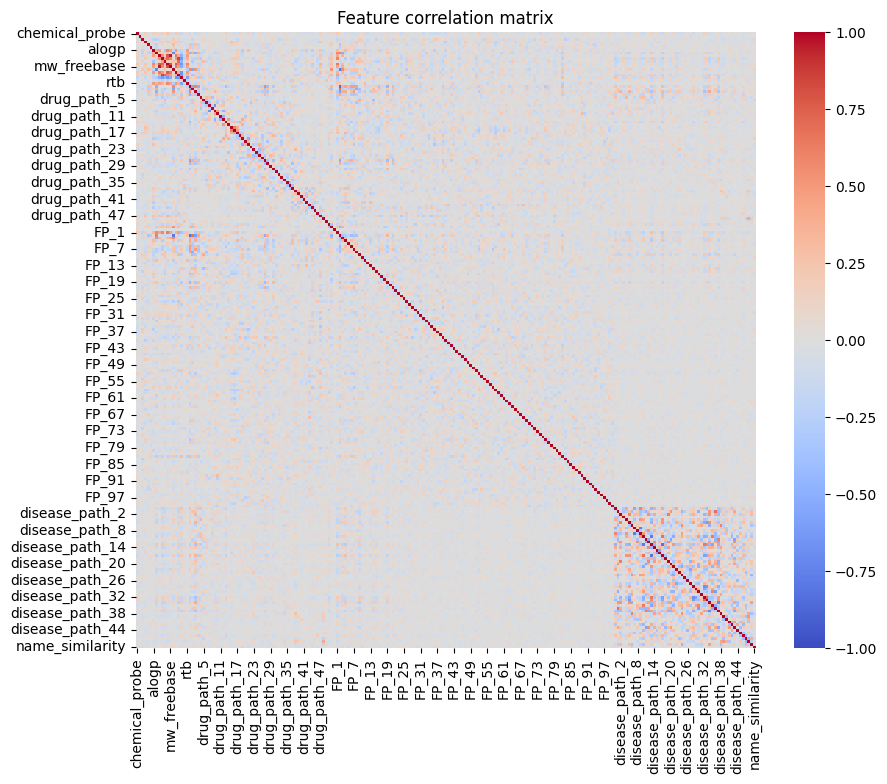

In [656]:
# don't consider some metrics
corr = (merged_df
        .select_dtypes(include=np.number)
        .corr())
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

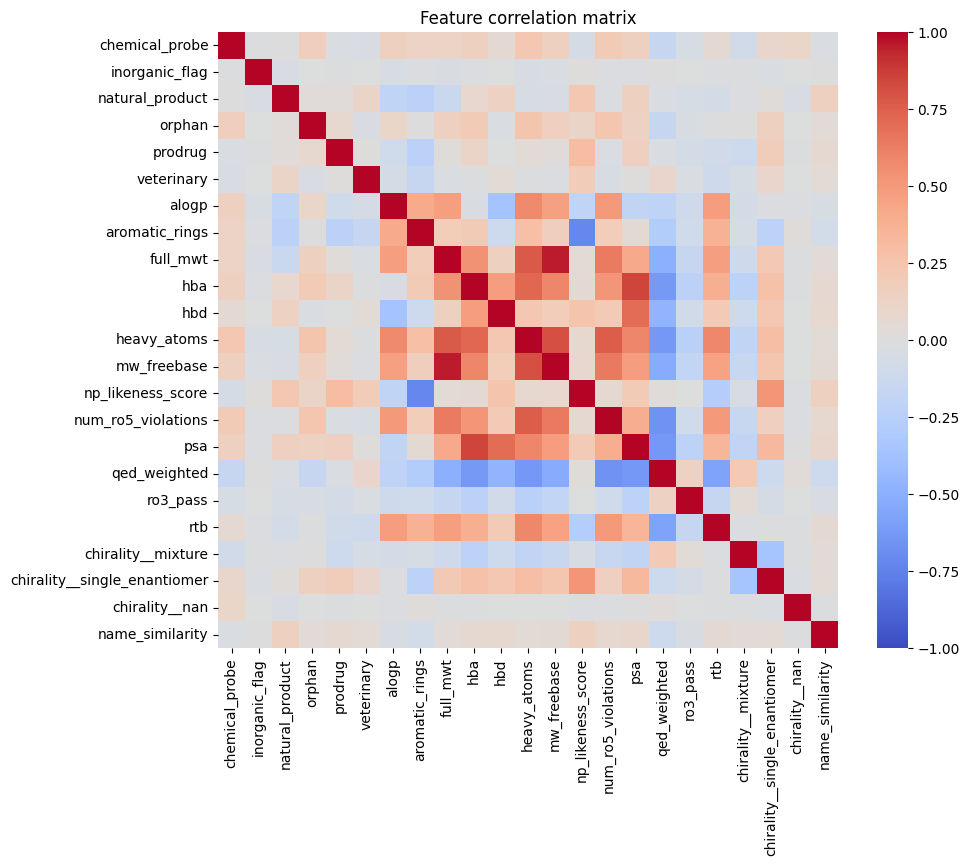

In [660]:
# close up for metrics with direct meaning
prefix_not_interpretable = ("FP", "drug_path", "disease_path")
merged_df_short = (merged_df
                .loc[:,~merged_df.columns.str.startswith(prefix_not_interpretable)]
                .select_dtypes(include=np.number))
corr = merged_df_short.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

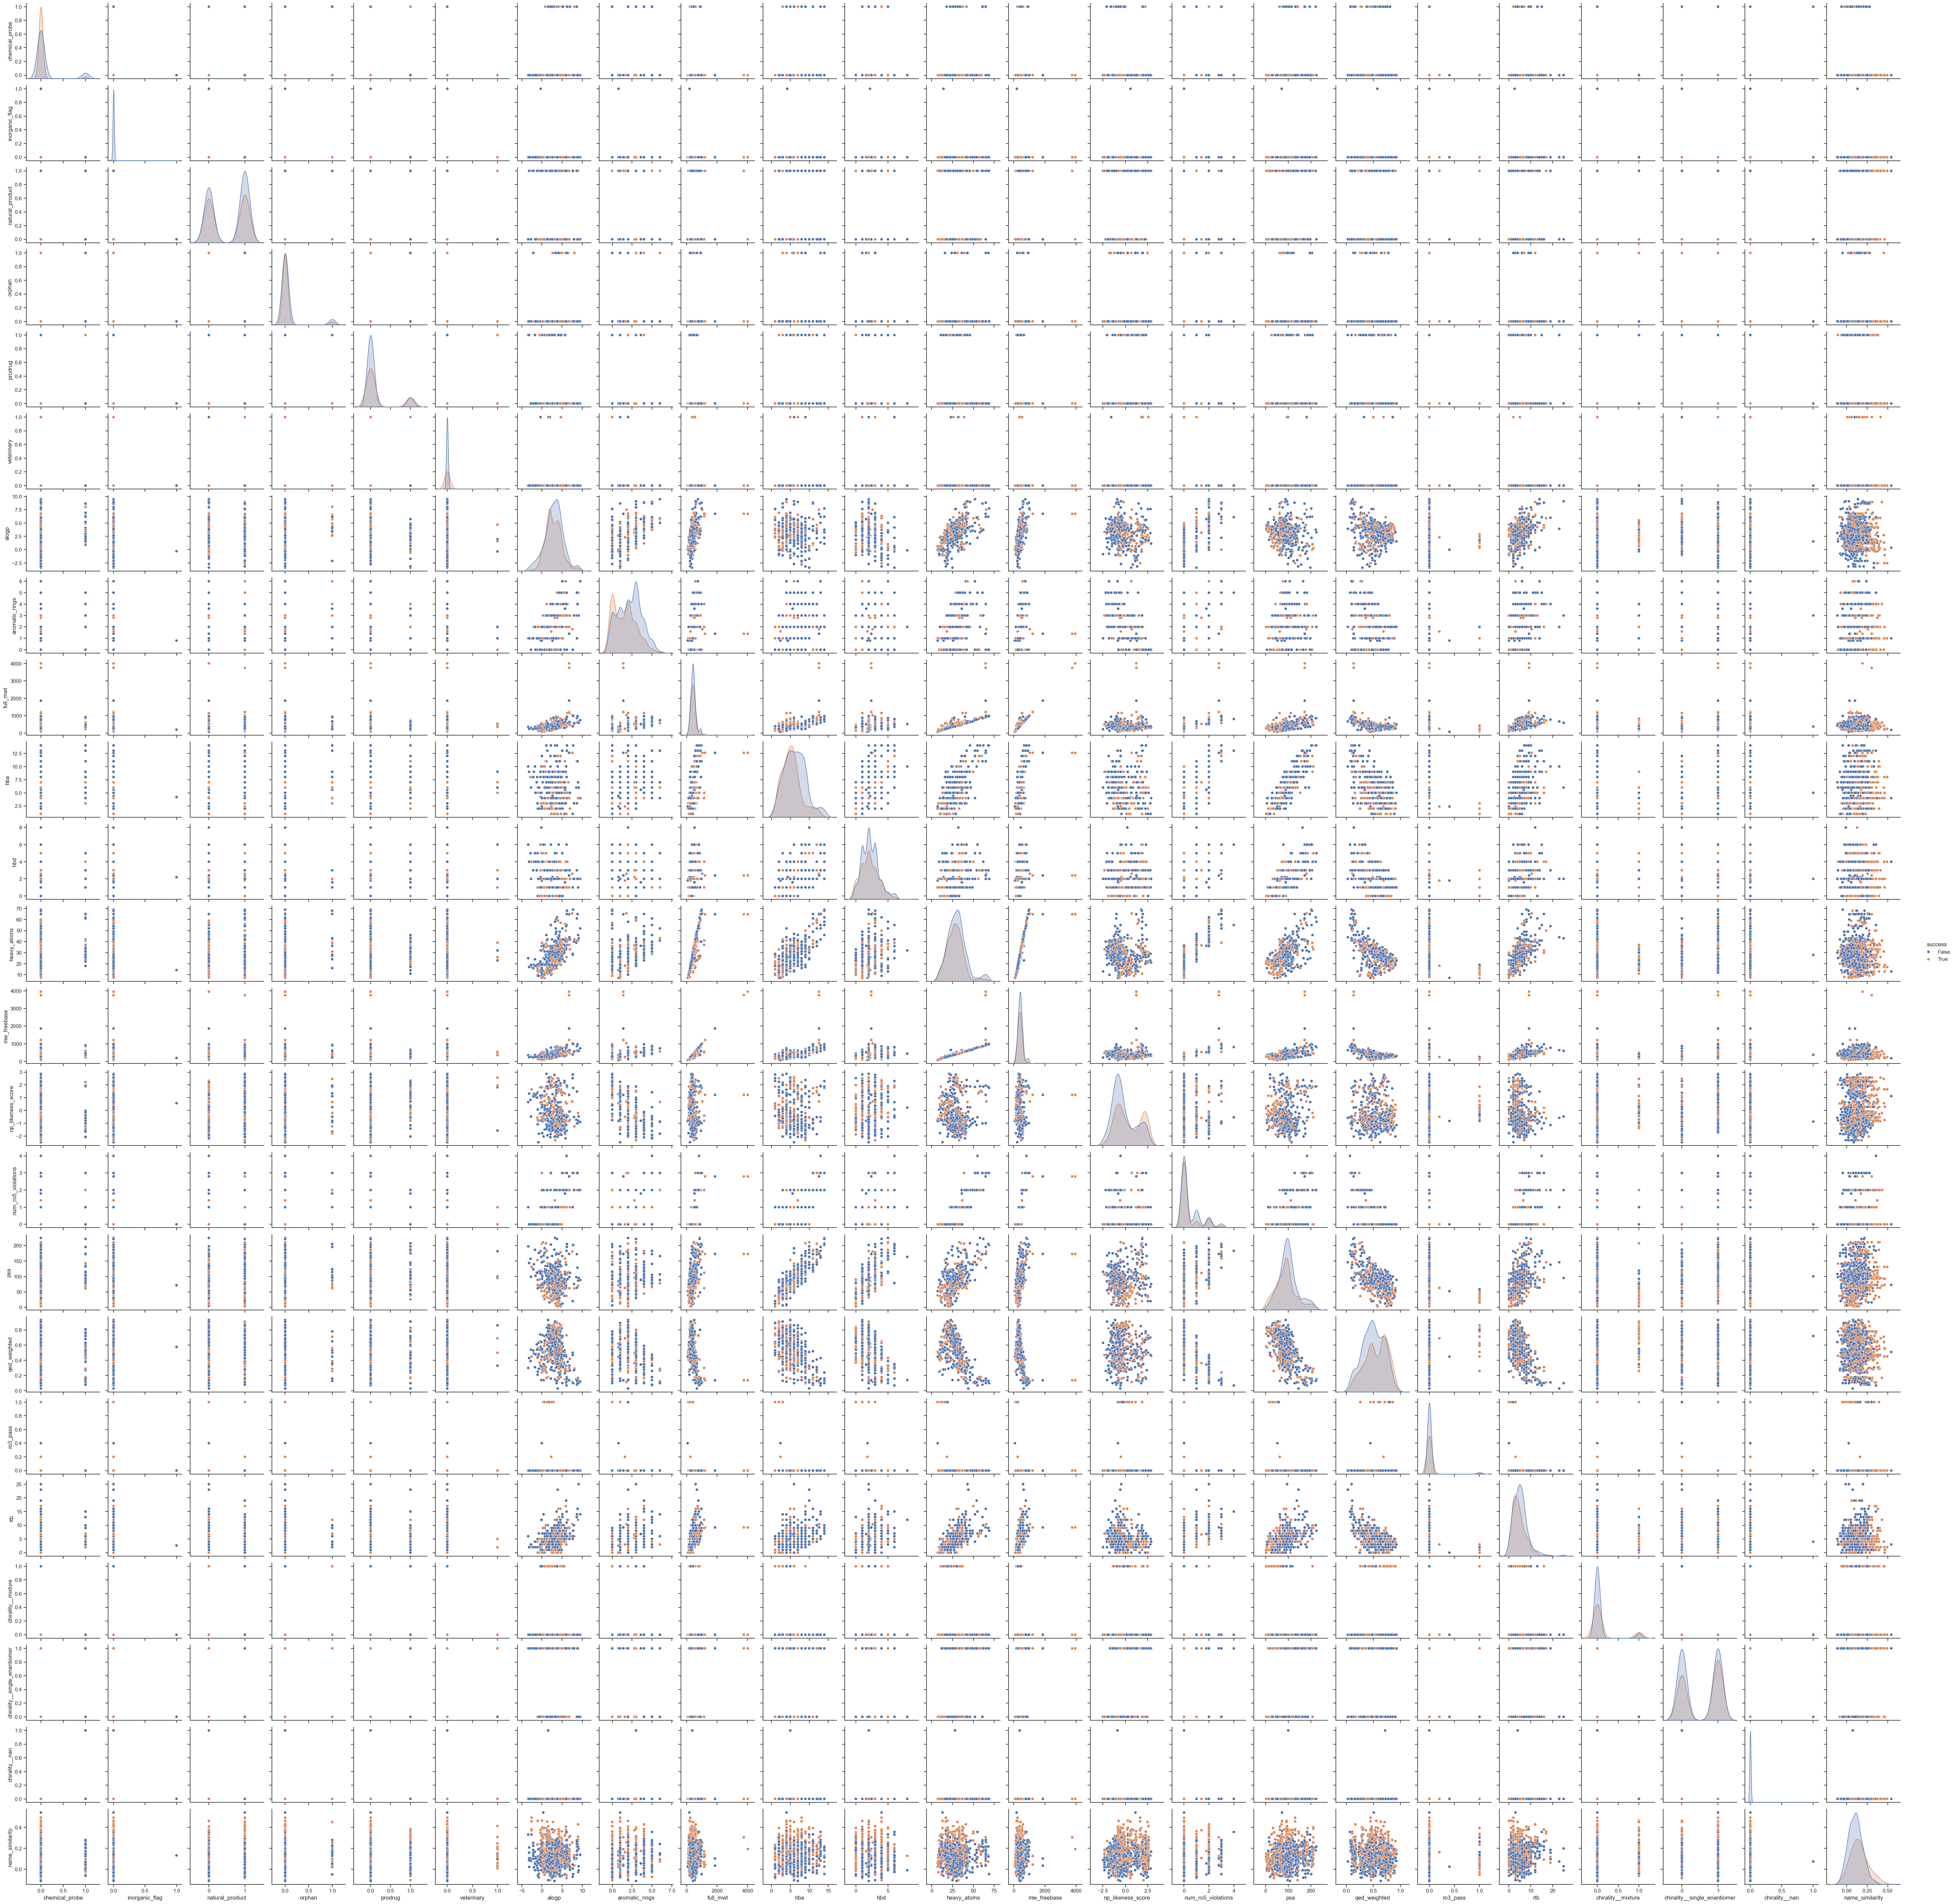

In [665]:
sns.set_theme(style="ticks")
sns.pairplot(merged_df_short.join(merged_df["success"]), hue="success")

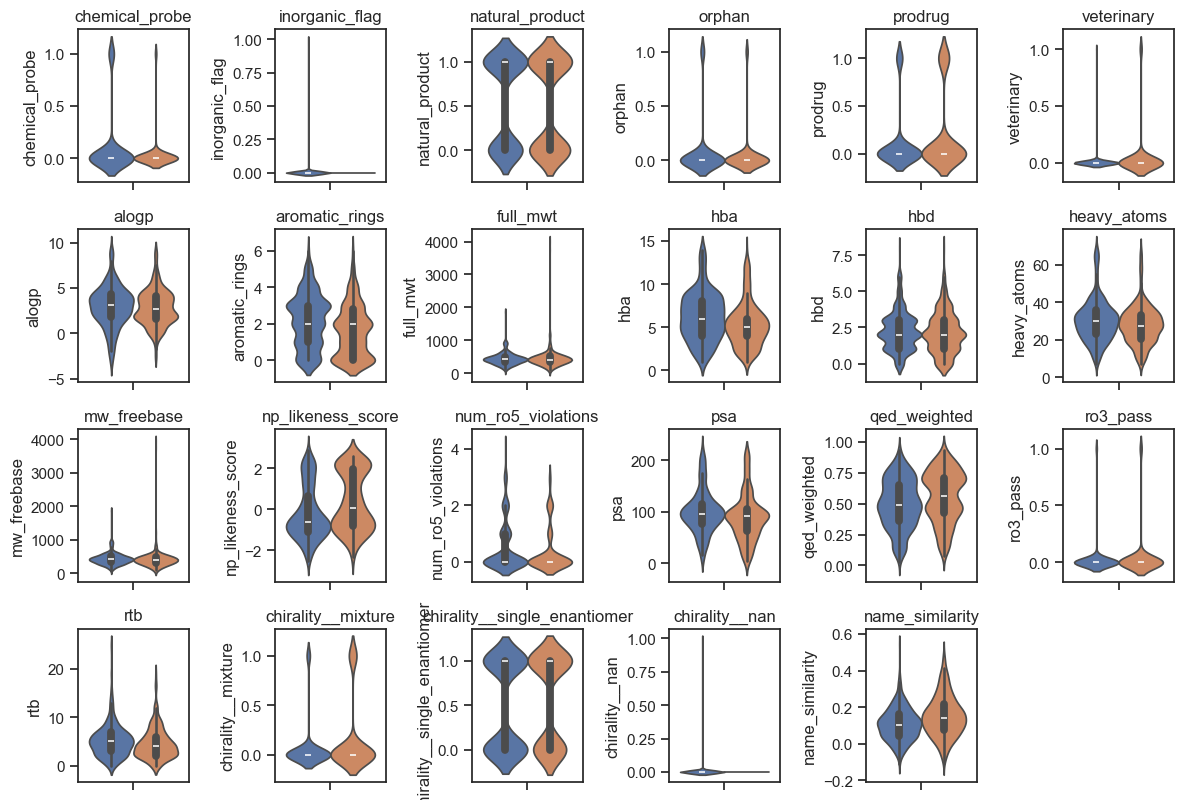

In [669]:
num_features = merged_df.select_dtypes(include=np.number).columns

n_cols = 6  # number of plots per row
n_rows = (len(num_features) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(num_features[~num_features.str.startswith(prefix_not_interpretable)]):
    sns.violinplot(y=merged_df[col], ax = axes[i], hue=merged_df["success"]);
    axes[i].set_title(col)
    axes[i].get_legend().remove()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Dimension reduction

In [650]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]
X_scaled = StandardScaler().fit_transform(X) # TODO: or don't scale for UMAP and tSNE?

def plot_dim_reduction(X, y, model_name=""):
    plt.figure()
    for label in np.unique(y):
        plt.scatter(X[y == label, 0], X[y == label, 1],
                    label= "success" if label else "fail", alpha=.5)
    plt.xlabel(model_name+"1")
    plt.ylabel(model_name+"2")
    plt.title(model_name)
    plt.legend()
    plt.grid(True)
    plt.show()

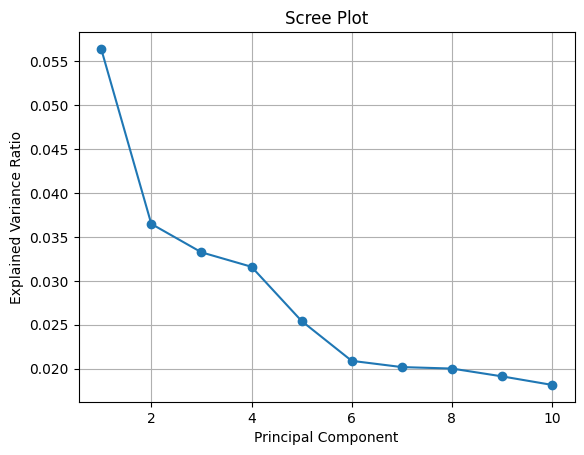

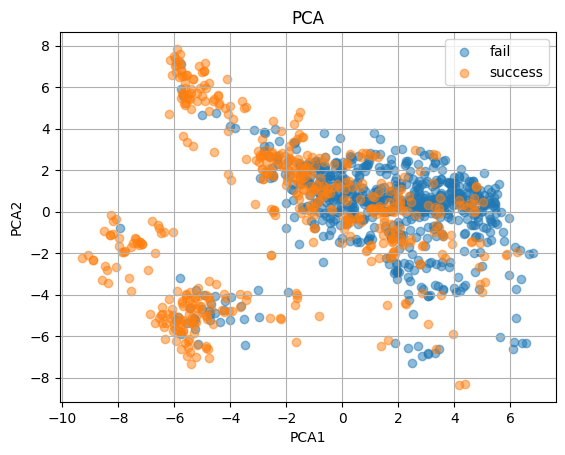

In [651]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

plot_dim_reduction(X_pca, y,"PCA")

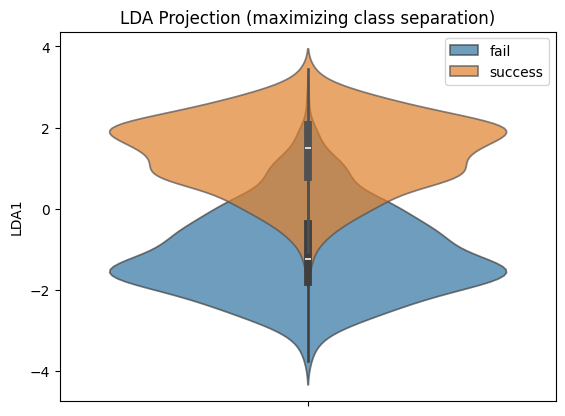

Explained variance ratio: [1.]


In [652]:
lda = LinearDiscriminantAnalysis(n_components=1)  # NOTE: n_components cannot be larger than min(n_features, n_classes - 1)
X_lda = lda.fit_transform(X_scaled, y)
plt.figure()
# sns.violinplot(data=pd.DataFrame({"LDA1": X_lda.flat, "success" : y}), y="LDA1", label="success")
for label in np.unique(y):
        sns.violinplot(X_lda[y == label, 0], alpha=0.7, label="success" if label else "fail")
plt.ylabel("LDA1")
plt.title("LDA Projection (maximizing class separation)")
plt.legend()
plt.show()

print("Explained variance ratio:", lda.explained_variance_ratio_)

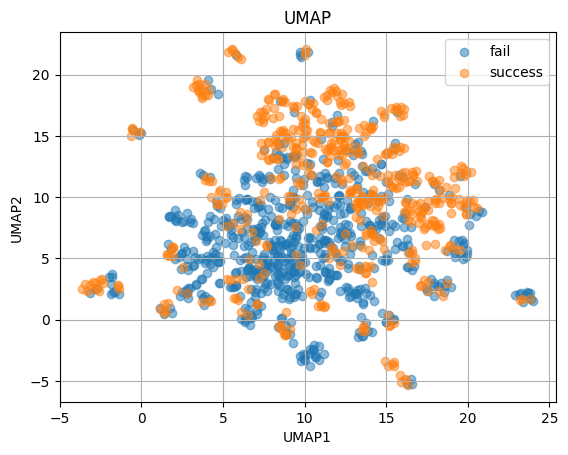

In [653]:
umap = UMAP(n_neighbors=10,min_dist=1,metric='correlation')
X_umap = umap.fit_transform(X_scaled) 
plot_dim_reduction(X_umap, y, "UMAP")

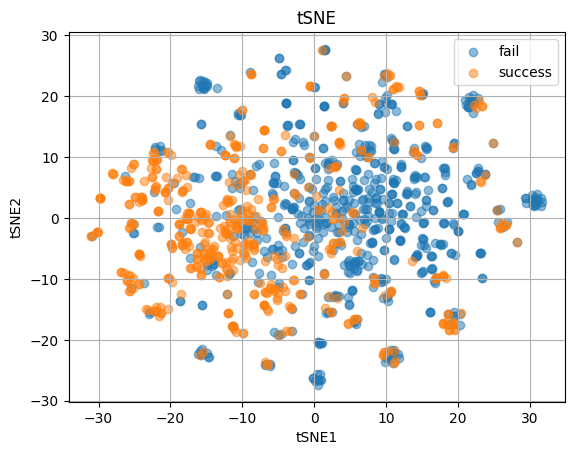

In [654]:
tsne = TSNE(n_components=2, perplexity=100)
X_tsne = tsne.fit_transform(X_scaled)
plot_dim_reduction(X_tsne, y, "tSNE")

# Save results

In [655]:
with open("../data/03-result/drugs_df.pkl","wb") as f:
    pickle.dump(drugs_df,f)
with open("../data/03-result/diseases_df.pkl","wb") as f:
    pickle.dump(diseases_df,f)
with open("../data/03-result/trials_df.pkl","wb") as f:
    pickle.dump(trials_df,f)
with open("../data/03-result/indications_df.pkl","wb") as f:
    pickle.dump(indications_df,f)
with open("../data/03-result/merged_df.pkl","wb") as f:
    pickle.dump(merged_df,f)